In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


In [2]:
data = pd.read_csv("dataset4.csv")

In [3]:
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())

(10000, 30)
Index(['video_id', 'category', 'region', 'language', 'duration_seconds',
       'creator_followers', 'creator_total_likes', 'creator_verified',
       'account_age_days', 'upload_hour', 'upload_weekday', 'hashtags_count',
       'caption_length', 'sound_popularity', 'effect_used',
       'posting_frequency_week', 'views', 'unique_viewers', 'likes',
       'comments', 'shares', 'favorites', 'profile_visits', 'watch_time_ratio',
       'completion_rate', 'engagement_rate', 'follower_view_ratio',
       'virality_score', 'trend_level', 'days_on_fyp'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                10000 non-null  object 
 1   category                10000 non-null  object 
 2   region                  10000 non-null  object 
 3   language                10000 non

In [19]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
video_id                  0
category                  0
region                    0
language                  0
duration_seconds          0
creator_followers         0
creator_total_likes       0
creator_verified          0
account_age_days          0
upload_hour               0
upload_weekday            0
hashtags_count            0
caption_length            0
sound_popularity          0
effect_used               0
posting_frequency_week    0
views                     0
unique_viewers            0
likes                     0
comments                  0
shares                    0
favorites                 0
profile_visits            0
watch_time_ratio          0
completion_rate           0
engagement_rate           0
follower_view_ratio       0
virality_score            0
trend_level               0
days_on_fyp               0
dtype: int64


# Feature Engineering

In [20]:
data["followers_per_post"] = data["creator_followers"] / (data["posting_frequency_week"] + 1)

data["likes_per_view"] = data["likes"] / (data["views"] + 1)

data["comments_per_view"] = data["comments"] / (data["views"] + 1)

data["shares_per_view"] = data["shares"] / (data["views"] + 1)

data["favorites_per_view"] = data["favorites"] / (data["views"] + 1)

data["total_engagement"] = (data["likes"] +data["comments"] +data["shares"] +data["favorites"])

# Feature Selection

In [21]:
features = [
    "category",
    "language",
    "duration_seconds",
    "caption_length",
    "hashtags_count",
    "sound_popularity",
    "effect_used",

    "creator_followers",
    "creator_total_likes",
    "creator_verified",
    "account_age_days",
    "posting_frequency_week",

    "region",
    "upload_hour",
    "upload_weekday",

    "watch_time_ratio",
    "completion_rate",

    "followers_per_post",
    "likes_per_view",
    "comments_per_view",
    "shares_per_view",
    "favorites_per_view",
    "total_engagement"
]

x = data[features]

y = data["trend_level"]

# Encoding

In [22]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "category",
    "region",
    "language",
    "upload_weekday"
]

encoders = {}
x = data[features].copy()
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    encoders[col] = le

# Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Model Architecture

In [24]:
model = Sequential([

    Input(shape=(X_train_scaled.shape[1],)),

    Dense(512, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.35),

    Dense(128, activation="relu", kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

In [25]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,787 (745.26 KB)

 Trainable params: 188,867 (737.76 KB)

 Non-trainable params: 1,920 (7.50 KB)

# Model Compilation






# Training Callbacks

In [27]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [28]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5226 - loss: 1.6273 - val_accuracy: 0.9287 - val_loss: 0.8711 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9161 - loss: 0.7261 - val_accuracy: 0.9469 - val_loss: 0.6528 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9313 - loss: 0.6353 - val_accuracy: 0.9463 - val_loss: 0.5972 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9409 - loss: 0.5804 - val_accuracy: 0.9444 - val_loss: 0.5666 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9485 - loss: 0.5462 - val_accuracy: 0.9500 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9466 - loss: 0.5251 - val_accuracy: 0.9638 - val_loss: 0.4799 - learning_rate: 0.0010
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9394 - loss: 0.5216 - val_acc

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


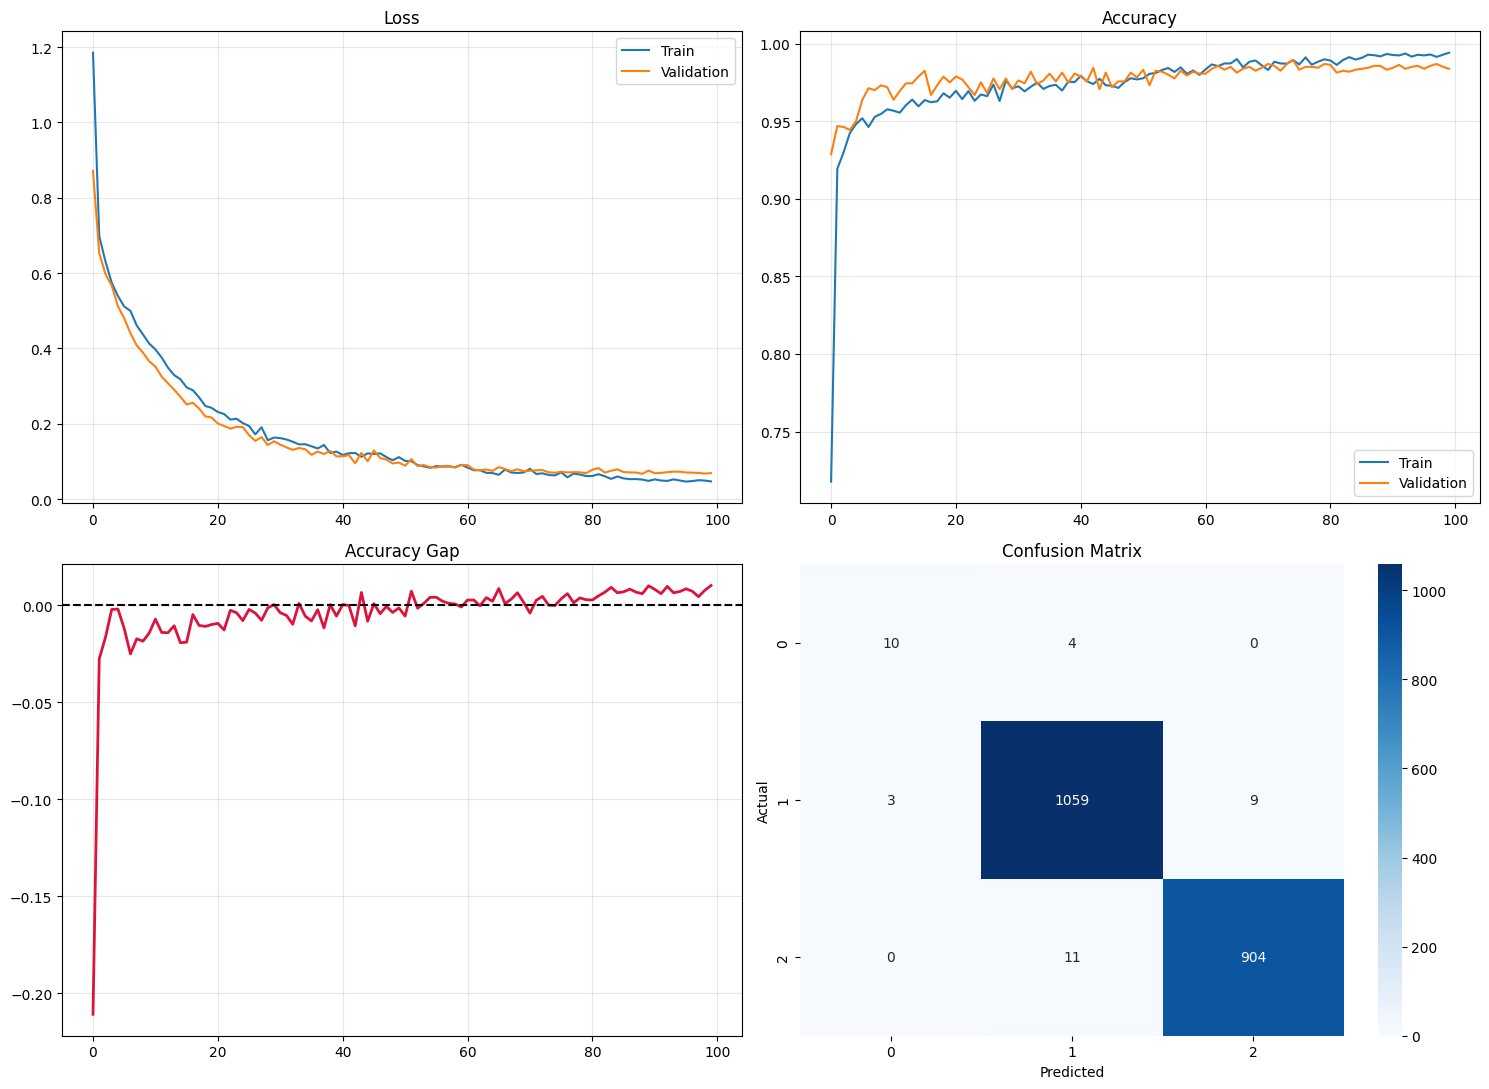

In [29]:
pred = model.predict(X_test_scaled)
pred_classes = np.argmax(pred, axis=1)
true_classes = y_test

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

axes[0,0].plot(history.history["loss"], label="Train")
axes[0,0].plot(history.history["val_loss"], label="Validation")
axes[0,0].set_title("Loss")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history.history["accuracy"], label="Train")
axes[0,1].plot(history.history["val_accuracy"], label="Validation")
axes[0,1].set_title("Accuracy")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

gap = np.array(history.history["accuracy"]) - np.array(history.history["val_accuracy"])
axes[1,0].plot(gap, color="crimson", linewidth=2)
axes[1,0].axhline(0, linestyle="--", color="black")
axes[1,0].set_title("Accuracy Gap")
axes[1,0].grid(alpha=0.3)


cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1,1])
axes[1,1].set_title("Confusion Matrix")
axes[1,1].set_xlabel("Predicted")
axes[1,1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import accuracy_score
import numpy as np

pred = model.predict(X_test_scaled, verbose=0)
pred = np.argmax(pred, axis=1)

acc = accuracy_score(y_test, pred)

print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9865
